# Week 8 Lab Exercise: Solution Key

**ARIMA, Box–Jenkins Methodology, Model Selection, Forecasting**

This notebook demonstrates the full Box–Jenkins workflow on the classic AirPassengers dataset:
EDA → Stationarity/Differencing (recap) → Identification (ACF/PACF) → Estimation (AIC/BIC) → Diagnostic checking → Forecasting → Evaluation.

**Aligned with:** Week 8 slides ("ARIMA, Box–Jenkins process, model selection, forecasting") and teaching content (week8A, week8B).

## 1. Setup and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

### Data source

This notebook supports **two environments**:

| Environment | Data path | How to set up |
|---|---|---|
| **Local / course repo** | `data/air_passengers.csv` | Run `generate_dataset.py` once |
| **Kaggle** | `/kaggle/input/air-passengers/AirPassengers.csv` | Add the dataset [chirag19/air-passengers](https://www.kaggle.com/datasets/chirag19/air-passengers) to your notebook |

The cell below auto-detects which environment is active.

In [2]:
import os

KAGGLE_PATH = "/kaggle/input/air-passengers/AirPassengers.csv"
LOCAL_PATH  = "data/air_passengers.csv"

if os.path.exists(KAGGLE_PATH):
    DATA_PATH = KAGGLE_PATH
    print(f"Kaggle environment detected — loading from: {DATA_PATH}")
else:
    DATA_PATH = LOCAL_PATH
    print(f"Local environment — loading from: {DATA_PATH}")

Local environment — loading from: data/air_passengers.csv


In [3]:
df = pd.read_csv(DATA_PATH)

# Kaggle version has columns "Month" / "#Passengers";
# local version has "date" / "Passengers".  Normalise both.
df.columns = (
    df.columns
    .str.strip()
    .str.replace("#Passengers", "Passengers", regex=False)
    .str.replace("Month", "date", regex=False)
)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
y = df["Passengers"]

print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print("\nDescribe:")
print(y.describe())
y.head()

Shape: (144, 1)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00

Describe:
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64


date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: Passengers, dtype: int64

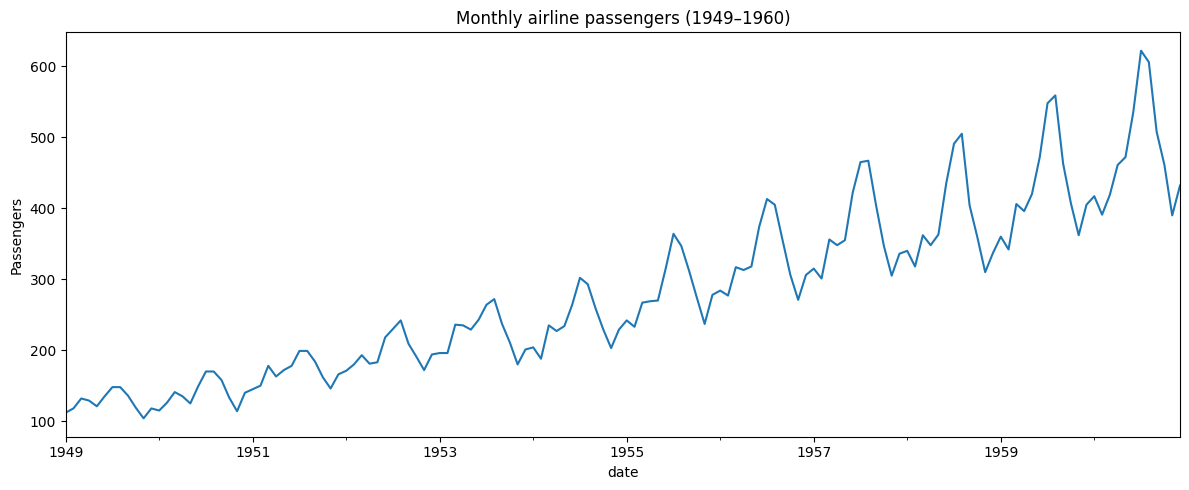

In [4]:
y.plot(title="Monthly airline passengers (1949–1960)", ylabel="Passengers")
plt.tight_layout()
plt.show()

**Observations:** The series shows a clear **upward trend** and **seasonal pattern** (yearly cycle with summer peaks). The variance appears to **increase with the level** (multiplicative seasonality). The series is clearly **non-stationary**.

---
## 2. Stationarity check and differencing (recap)

This step was covered in **Weeks 6–7** (slides 4.1 and 4.2). Here we briefly confirm that the raw series has a unit root and that first differencing produces a (more) stationary series, so we can set **d = 1** for the Box–Jenkins pipeline.

**ADF test reminder:**
- $H_0$: the series has a unit root (non-stationary).
- Small p-value (≤ 0.05) → reject $H_0$ → stationary.
- Large p-value → do not reject → non-stationary.

In [5]:
def run_adf(series, label=""):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF test ({label}):")
    print(f"  Test statistic: {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.4f}")
    print(f"  Lags used:      {result[2]}")
    for k, v in result[4].items():
        print(f"  Critical {k}: {v:.4f}")
    print()
    return result

adf_raw = run_adf(y, "raw series")

ADF test (raw series):
  Test statistic: 0.8154
  p-value:        0.9919
  Lags used:      13
  Critical 1%: -3.4817
  Critical 5%: -2.8840
  Critical 10%: -2.5788



The p-value is large → we **do not reject** the unit root → the raw series is **non-stationary**. We proceed to differencing.

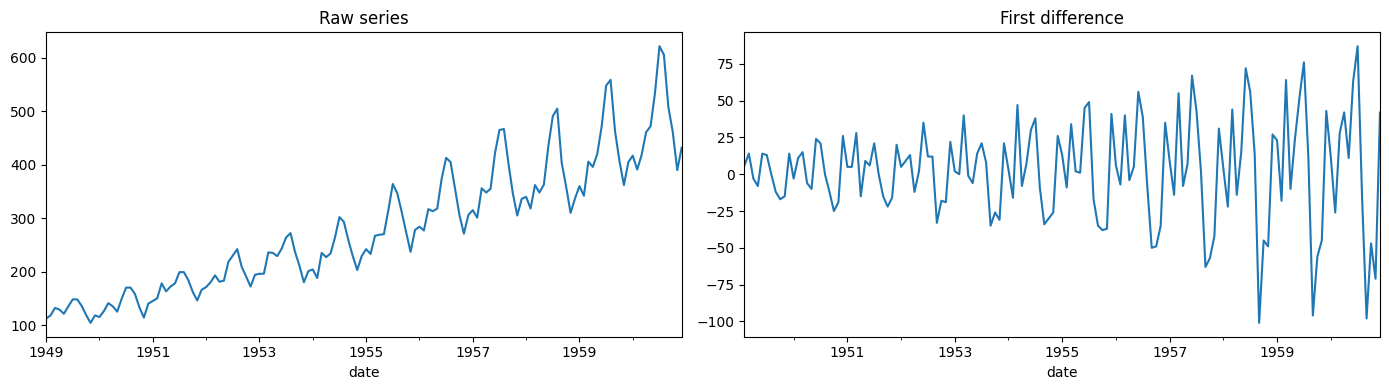

ADF test (first difference):
  Test statistic: -2.8293
  p-value:        0.0542
  Lags used:      12
  Critical 1%: -3.4817
  Critical 5%: -2.8840
  Critical 10%: -2.5788



In [6]:
dy = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
y.plot(ax=axes[0], title="Raw series")
dy.plot(ax=axes[1], title="First difference")
plt.tight_layout()
plt.show()

adf_diff = run_adf(dy, "first difference")

The differenced series has a **small p-value** → we **reject** the unit root → the first difference is **stationary** (at least in terms of the unit root). We set **d = 1**.

> **Note:** The differenced series still shows some seasonal pattern. A non-seasonal ARIMA(p,1,q) will not fully capture that; SARIMA (Week 11) is the proper extension. Here we proceed with ARIMA to practise the Box–Jenkins methodology.

---
## 3. Box–Jenkins Identification

### The Box–Jenkins cycle (slides 14–26)

The Box–Jenkins approach is an **iterative** four-step procedure:

1. **Identification:** Choose d (done above, d=1). Then choose (p, q) using the ACF and PACF of the **differenced** series.
2. **Estimation:** Fit the ARIMA(p,d,q) model by maximum likelihood.
3. **Diagnostic checking:** Test whether the residuals behave like white noise (ACF of residuals, Ljung–Box test). If not, return to step 1 and try different orders.
4. **Forecasting:** Use the adequate model to produce forecasts and evaluate them.

### Identification guidelines

Work with the differenced series $W_t = \nabla X_t$:

- **PACF** cuts off after lag p → try AR(p) on $W_t$ → **ARIMA(p, 1, 0)**
- **ACF** cuts off after lag q → try MA(q) on $W_t$ → **ARIMA(0, 1, q)**
- Both tail off → try **ARIMA(p, 1, q)** with small p, q

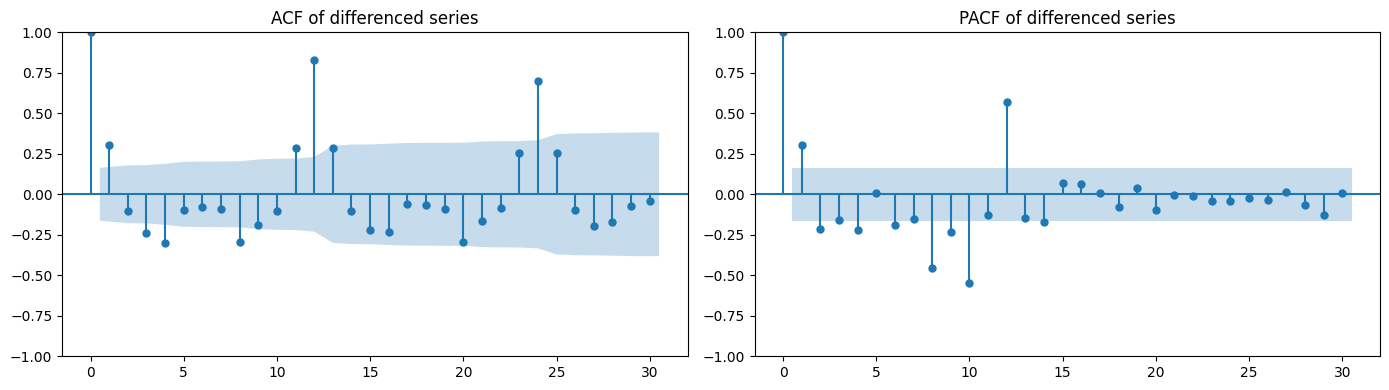

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(dy, lags=30, ax=axes[0], title="ACF of differenced series")
plot_pacf(dy, lags=30, ax=axes[1], title="PACF of differenced series", method="ywm")
plt.tight_layout()
plt.show()

### Interpretation

- The **ACF** shows a significant spike at lag 1 and significant spikes at seasonal lags (12, 24). The non-seasonal ACF structure suggests an MA component of order 1.
- The **PACF** shows spikes at lags 1–2 and seasonal lags. The non-seasonal PACF structure suggests an AR component of order 1–2.

**Candidate orders** (focusing on non-seasonal ARIMA for Week 8):

| Candidate | Rationale |
|-----------|----------|
| ARIMA(1,1,0) | PACF cuts off after lag 1 |
| ARIMA(0,1,1) | ACF cuts off after lag 1 |
| ARIMA(1,1,1) | Both AR and MA terms |
| ARIMA(2,1,1) | Allow an extra AR lag |

We will fit all four and compare using AIC/BIC in the next step.

---
## 4. Estimation and AIC/BIC model selection

### Information criteria (slides 28–39)

After fitting each candidate model by **maximum likelihood**, we compare them using:

- **AIC** (Akaike): $\mathrm{AIC} = -2 \ln L + 2k$
- **BIC** (Bayesian / Schwarz): $\mathrm{BIC} = -2 \ln L + k \ln n$

where $L$ = maximized likelihood, $k$ = number of parameters, $n$ = sample size.

**Lower is better.** BIC penalizes complexity more than AIC (since $\ln n > 2$ for $n > 7$), so it tends to favour **simpler models** (parsimony). We typically prefer the model with the **lowest BIC**, unless AIC points to a clearly better fit.

In [8]:
candidates = [(1,1,0), (0,1,1), (1,1,1), (2,1,1)]
results = []

for order in candidates:
    try:
        model = ARIMA(y, order=order)
        fit = model.fit()
        results.append({
            "Order": f"ARIMA{order}",
            "AIC": round(fit.aic, 2),
            "BIC": round(fit.bic, 2),
            "Log-Lik": round(fit.llf, 2),
            "Params": {k: round(v, 4) for k, v in fit.params.items()},
        })
        print(f"ARIMA{order}: AIC = {fit.aic:.2f}, BIC = {fit.bic:.2f}")
    except Exception as e:
        print(f"ARIMA{order}: FAILED ({e})")

comparison = pd.DataFrame(results)
print("\n--- Model Comparison ---")
print(comparison[["Order", "AIC", "BIC"]].to_string(index=False))

ARIMA(1, 1, 0): AIC = 1401.85, BIC = 1407.78
ARIMA(0, 1, 1): AIC = 1397.26, BIC = 1403.18
ARIMA(1, 1, 1): AIC = 1394.68, BIC = 1403.57
ARIMA(2, 1, 1): AIC = 1378.34, BIC = 1390.19

--- Model Comparison ---
         Order     AIC     BIC
ARIMA(1, 1, 0) 1401.85 1407.78
ARIMA(0, 1, 1) 1397.26 1403.18
ARIMA(1, 1, 1) 1394.68 1403.57
ARIMA(2, 1, 1) 1378.34 1390.19


In [9]:
best_idx = comparison["BIC"].idxmin()
best_order_str = comparison.loc[best_idx, "Order"]
print(f"Preferred model by BIC: {best_order_str}")

# Extract the tuple back from the best row
best_order = candidates[best_idx]

fit_best = ARIMA(y, order=best_order).fit()
print(fit_best.summary())

Preferred model by BIC: ARIMA(2, 1, 1)
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -685.169
Date:                Mon, 09 Mar 2026   AIC                           1378.338
Time:                        15:48:54   BIC                           1390.190
Sample:                    01-01-1949   HQIC                          1383.154
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0907      0.083     13.190      0.000       0.929       1.253
ar.L2         -0.4890      0.097     -5.046      0.000      -0.679      -0.299
ma.L1        

### Discussion

The model with the **lowest BIC** is our preferred choice. BIC's stronger penalty for extra parameters helps guard against **overfitting**: a model with more parameters will always fit the training data better (lower $-2\ln L$), but the extra complexity may not generalise to new data. BIC balances fit and parsimony.

> **Note:** Because this dataset has strong **seasonality**, none of these non-seasonal ARIMA models will capture the yearly pattern perfectly. The AIC/BIC values reflect fit quality *within* the ARIMA class; a SARIMA model (Week 11) would achieve substantially better fit.

---
## 5. Residual diagnostics

### White-noise requirement (slides 28–39)

If the model is adequate, the **residuals** $\hat{\varepsilon}_t$ should behave like **white noise**:
- Zero mean
- Constant variance
- **No autocorrelation** (residuals at different times are uncorrelated)

We check this with:
1. **ACF of residuals:** All spikes should be inside the confidence band $\pm 1.96 / \sqrt{n}$.
2. **Ljung–Box test:** $H_0$: residuals are uncorrelated up to lag $K$. Large p-value ($> 0.05$) → do not reject → residuals consistent with white noise. Small p-value → reject → model inadequate.
3. **Histogram / QQ-plot:** Check for approximate normality (needed for valid forecast intervals).

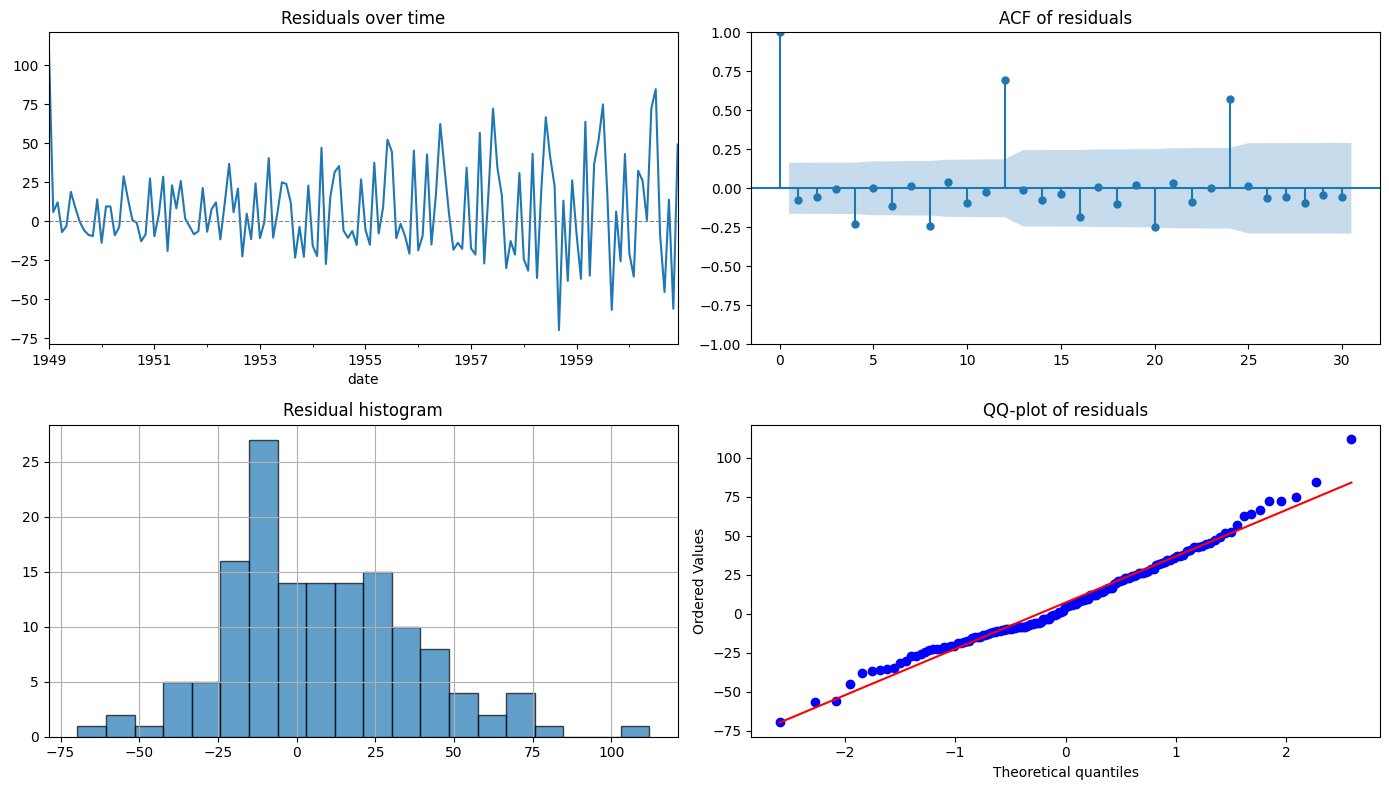

In [10]:
resid = fit_best.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
resid.plot(ax=axes[0, 0], title="Residuals over time")
axes[0, 0].axhline(0, color="grey", linestyle="--", linewidth=0.8)

# ACF of residuals
plot_acf(resid, lags=30, ax=axes[0, 1], title="ACF of residuals")

# Histogram
resid.hist(ax=axes[1, 0], bins=20, edgecolor="black", alpha=0.7)
axes[1, 0].set_title("Residual histogram")

# QQ-plot
from scipy import stats
stats.probplot(resid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ-plot of residuals")

plt.tight_layout()
plt.show()

In [11]:
lb = acorr_ljungbox(resid, lags=20, return_df=True)
print("Ljung-Box test (residuals):")
print(lb.to_string())

Ljung-Box test (residuals):
       lb_stat     lb_pvalue
1     0.790738  3.738770e-01
2     1.242041  5.373958e-01
3     1.246317  7.419184e-01
4     9.070758  5.935499e-02
5     9.070801  1.062733e-01
6    11.048705  8.688275e-02
7    11.095050  1.345264e-01
8    20.102828  9.953943e-03
9    20.369526  1.576395e-02
10   21.847917  1.589839e-02
11   21.961192  2.467562e-02
12   98.529132  1.080404e-15
13   98.539378  3.181529e-15
14   99.454629  6.032344e-15
15   99.661506  1.512353e-14
16  105.051167  3.884313e-15
17  105.069804  1.013724e-14
18  106.838806  1.216681e-14
19  106.903314  2.956504e-14
20  117.229978  9.268933e-16


### Interpretation

- **ACF of residuals:** Significant spikes at seasonal lags (e.g. 12) indicate remaining **seasonal autocorrelation** that the non-seasonal ARIMA cannot capture. For non-seasonal lags, the ACF is mostly within the bands.
- **Ljung–Box:** Some p-values may be small at higher lags (especially around lag 12), reflecting the seasonal structure. This tells us the model is **not fully adequate** — exactly the expected outcome with a non-seasonal ARIMA on a seasonal series.
- **Histogram / QQ-plot:** Residuals are approximately normal with some outliers in the tails.

**What to do if diagnostics fail:** In the Box–Jenkins methodology, we would **return to Identification** and try different orders. Here, the root cause is **seasonality**, which requires **SARIMA** (Week 11). For the purpose of this exercise, we proceed with the current model to practise the forecasting and evaluation steps.

> **Key takeaway:** Residual diagnostics are not just a checkbox — they reveal *what the model misses* and guide the next iteration of the Box–Jenkins cycle.

---
## 6. Multi-step forecast

### Multi-step forecasting (slides 41–54)

In a **multi-step forecast**, we fit the model **once** on the training data and then predict $h$ steps into the future in one shot using `fit.forecast(steps=h)`.

**Long-horizon behaviour:** For a stationary ARMA process, the forecast mean **reverts to the unconditional mean** as $h$ increases, and the forecast variance grows toward the unconditional variance. When we reconstruct the level $X_{n+h}$ from the differenced forecasts, the long-horizon forecast often looks like a **straight line** (the series "flattens out"). This is a fundamental property of ARIMA forecasts, not a bug.

In [12]:
n_test = 24
train, test = y.iloc[:-n_test], y.iloc[-n_test:]
print(f"Train: {train.index[0]} to {train.index[-1]} ({len(train)} obs)")
print(f"Test:  {test.index[0]} to {test.index[-1]} ({len(test)} obs)")

Train: 1949-01-01 00:00:00 to 1958-12-01 00:00:00 (120 obs)
Test:  1959-01-01 00:00:00 to 1960-12-01 00:00:00 (24 obs)


In [13]:
model_f = ARIMA(train, order=best_order)
fit_f = model_f.fit()
forecast_ms = fit_f.forecast(steps=n_test)

rmse_ms = np.sqrt(np.mean((test.values - forecast_ms.values) ** 2))
mae_ms = np.mean(np.abs(test.values - forecast_ms.values))
print(f"Multi-step forecast:")
print(f"  RMSE: {rmse_ms:.2f}")
print(f"  MAE:  {mae_ms:.2f}")

Multi-step forecast:


  RMSE: 102.63
  MAE:  75.66


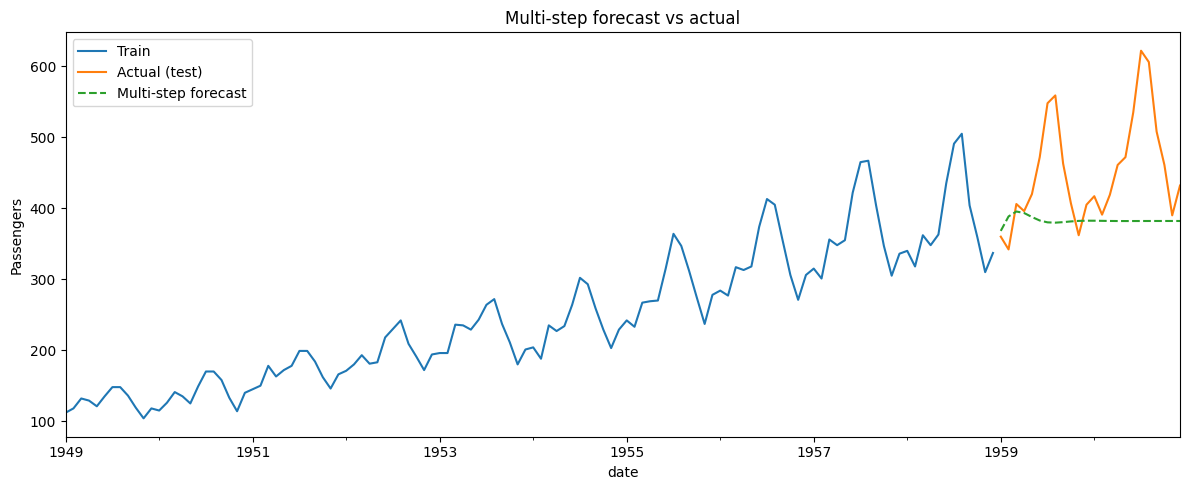

In [14]:
plt.figure(figsize=(12, 5))
train.plot(label="Train", legend=True)
test.plot(label="Actual (test)", legend=True)
pd.Series(forecast_ms.values, index=test.index).plot(
    label="Multi-step forecast", legend=True, linestyle="--"
)
plt.title("Multi-step forecast vs actual")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

**Observation:** The multi-step forecast produces a **relatively smooth line** that follows the general trend but cannot capture the seasonal ups and downs. This is expected: (1) a non-seasonal ARIMA does not model the yearly cycle, and (2) the forecast mean reverts toward the long-run trend, smoothing out short-term variation.

---
## 7. Rolling one-step-ahead forecast

### Rolling one-step-ahead (slides 41–54)

Instead of forecasting the entire test horizon from a single fit, we forecast **one step at a time**. At each test point $t$, we:
1. Use all data up to $t-1$ (optionally **re-estimate** the model).
2. Forecast only $X_t$ (one step ahead).
3. Move to $t+1$ and repeat.

**Why it tracks better:** Each forecast uses the **most recent information** and predicts only the next value, so errors do not compound over many steps. With re-estimation, the parameters also adapt to the latest data.

**Trade-off:** More computationally expensive (re-fitting at each step), but typically produces **lower RMSE/MAE** on the test set.

In [15]:
rolling_preds = []
history = list(train.values)

for t in range(len(test)):
    model_roll = ARIMA(history, order=best_order)
    fit_roll = model_roll.fit()
    pred = fit_roll.forecast(steps=1)
    rolling_preds.append(float(np.asarray(pred).flat[0]))
    history.append(test.values[t])

rolling_forecast = pd.Series(rolling_preds, index=test.index)

rmse_roll = np.sqrt(np.mean((test.values - rolling_forecast.values) ** 2))
mae_roll = np.mean(np.abs(test.values - rolling_forecast.values))

print("Rolling 1-step (re-estimate each step):")
print(f"  RMSE: {rmse_roll:.2f}")
print(f"  MAE:  {mae_roll:.2f}")

Rolling 1-step (re-estimate each step):
  RMSE: 44.73
  MAE:  38.31


In [16]:
print("\n--- Forecast Comparison ---")
comp_df = pd.DataFrame({
    "Method": ["Multi-step", "Rolling 1-step"],
    "RMSE": [round(rmse_ms, 2), round(rmse_roll, 2)],
    "MAE": [round(mae_ms, 2), round(mae_roll, 2)],
})
print(comp_df.to_string(index=False))


--- Forecast Comparison ---
        Method   RMSE   MAE
    Multi-step 102.63 75.66
Rolling 1-step  44.73 38.31


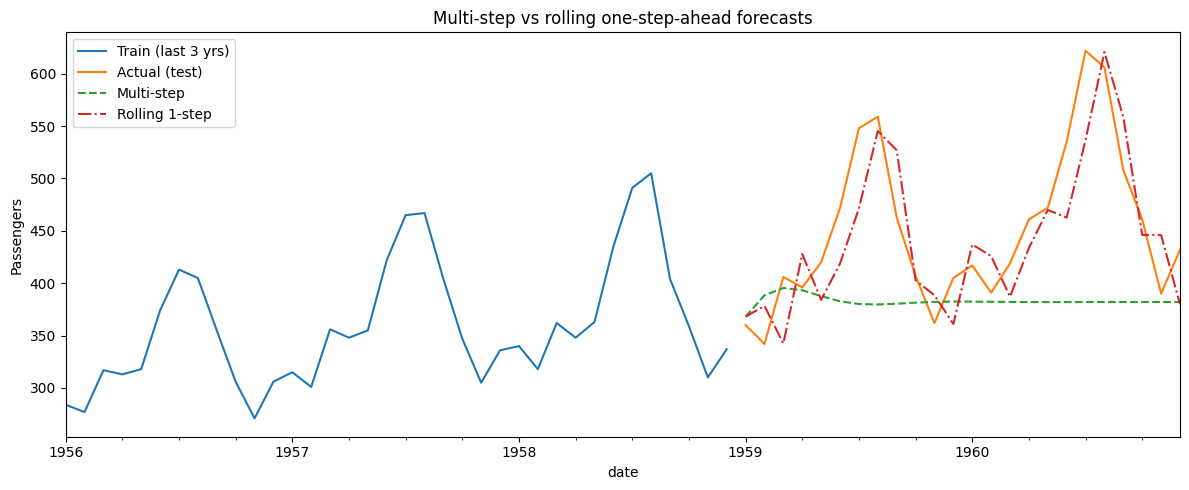

In [17]:
plt.figure(figsize=(12, 5))
train[-36:].plot(label="Train (last 3 yrs)", legend=True)
test.plot(label="Actual (test)", legend=True)
pd.Series(forecast_ms.values, index=test.index).plot(
    label="Multi-step", legend=True, linestyle="--"
)
rolling_forecast.plot(label="Rolling 1-step", legend=True, linestyle="-.")
plt.title("Multi-step vs rolling one-step-ahead forecasts")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

### Interpretation

- The **rolling one-step-ahead** forecast **tracks the actual series more closely** than the multi-step forecast, with lower RMSE and MAE.
- The multi-step forecast shows the characteristic **flattening** (mean reversion) at longer horizons.
- Even the rolling forecast cannot capture the seasonal peaks and troughs perfectly, since the underlying ARIMA model is non-seasonal.

**When to use which:**
- **Multi-step:** When you need forecasts for a fixed future horizon from today (e.g. budget planning for the next 12 months).
- **Rolling one-step:** When evaluating how well the model would have predicted in real time, or when you can re-fit the model as new data arrives.

---
## 8. Forecast intervals

### Prediction intervals (slides 41–54)

In addition to point forecasts, we often need **forecast intervals** (e.g. 95%) that quantify uncertainty:

$$P(L_{n+h} \leq X_{n+h} \leq U_{n+h}) \approx 0.95$$

The interval accounts for:
1. **Innovation uncertainty:** Future shocks $\varepsilon_{n+1}, \ldots, \varepsilon_{n+h}$ are unknown.
2. **Parameter uncertainty:** We use estimated (not true) coefficients.

The interval **widens** as the horizon $h$ increases, because uncertainty accumulates.

In Statsmodels, use `get_forecast(steps=h)` which returns `.predicted_mean` and `.conf_int(alpha=0.05)` for the 95% interval.

In [18]:
fcast = fit_f.get_forecast(steps=n_test)
fc_mean = fcast.predicted_mean
fc_ci = fcast.conf_int(alpha=0.05)

print("Forecast with 95% confidence interval (first 6 months):")
interval_df = pd.DataFrame({
    "Forecast": fc_mean.values,
    "Lower 95%": fc_ci.iloc[:, 0].values,
    "Upper 95%": fc_ci.iloc[:, 1].values,
    "Actual": test.values,
}, index=test.index)
print(interval_df.head(6).to_string())

Forecast with 95% confidence interval (first 6 months):
              Forecast   Lower 95%   Upper 95%  Actual
date                                                  
1959-01-01  368.118819  319.027264  417.210374     360
1959-02-01  388.482227  310.740540  466.223914     342
1959-03-01  395.466819  303.551402  487.382236     406
1959-04-01  393.294708  296.031646  490.557770     396
1959-05-01  387.692329  288.632090  486.752567     420
1959-06-01  382.758772  282.841585  482.675959     472


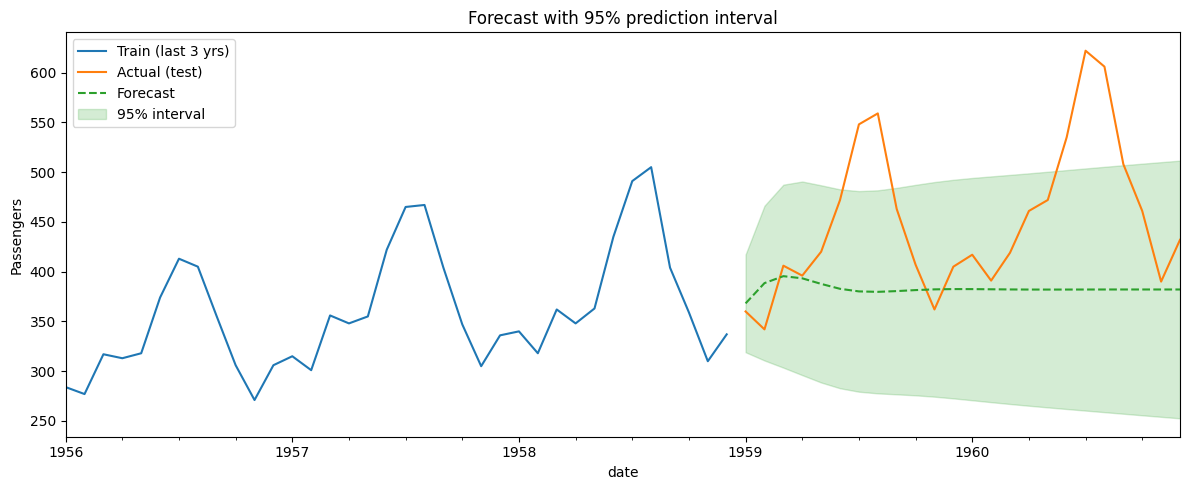

In [19]:
plt.figure(figsize=(12, 5))
train[-36:].plot(label="Train (last 3 yrs)", legend=True)
test.plot(label="Actual (test)", legend=True, color="tab:orange")
fc_mean_series = pd.Series(fc_mean.values, index=test.index)
fc_mean_series.plot(label="Forecast", legend=True, linestyle="--", color="tab:green")
plt.fill_between(
    test.index,
    fc_ci.iloc[:, 0].values,
    fc_ci.iloc[:, 1].values,
    alpha=0.2,
    color="tab:green",
    label="95% interval",
)
plt.title("Forecast with 95% prediction interval")
plt.ylabel("Passengers")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- The **95% interval widens** as the forecast horizon increases, reflecting growing uncertainty about the future.
- At short horizons, the interval is relatively narrow and most actual values fall within it. At longer horizons, the interval becomes very wide, indicating that the model has limited predictive power far into the future.
- Some actual values fall **outside** the interval, particularly at seasonal peaks. This confirms that the non-seasonal ARIMA systematically misses the seasonal pattern.

**Practical implication:** Wide intervals at long horizons mean that point forecasts should be used cautiously for long-range planning. Narrower intervals (better forecasts) would require a seasonal model (SARIMA) or additional covariates.

---
## 9. Summary and conclusions

### What we did

1. **Loaded** the AirPassengers dataset (144 monthly observations, 1949–1960) and confirmed a clear trend and seasonal pattern.
2. **Confirmed non-stationarity** via ADF; set d = 1 after first differencing.
3. **Identified** candidate ARIMA orders from ACF/PACF of the differenced series: (1,1,0), (0,1,1), (1,1,1), (2,1,1).
4. **Estimated** all candidates and compared AIC/BIC; chose the model with the lowest BIC.
5. **Diagnosed** residuals: ACF, Ljung–Box, histogram, QQ-plot. Found remaining seasonal autocorrelation (expected with non-seasonal ARIMA).
6. **Forecasted** with multi-step and rolling one-step-ahead methods; rolling one-step tracked actuals better (lower RMSE/MAE).
7. **Produced 95% forecast intervals** and observed widening with horizon.

### Key takeaways

- The **Box–Jenkins methodology** provides a systematic, iterative framework: Identify → Estimate → Diagnose → Forecast. If diagnostics fail, iterate.
- **AIC/BIC** help choose among candidate models; BIC favours parsimony.
- **Residual diagnostics** (ACF + Ljung–Box) reveal what the model misses; here, the seasonal structure.
- **Rolling one-step** forecasts track the series better than multi-step, but are more expensive.
- **Forecast intervals** widen with horizon; they are essential for honest uncertainty communication.
- A **non-seasonal ARIMA** has clear limitations on seasonal data. **SARIMA** (Week 11) addresses this by adding seasonal AR/MA/differencing terms.

### References

- **Slides:** Week 8 – "ARIMA, Box–Jenkins process, model selection, forecasting" (55 slides)
- **Teaching content:** `../week8/week8A_teaching_content.md` (theory), `../week8/week8B_teaching_content.md` (practice)
- **Textbooks:** Kirchgässner & Wolters (2013); Atwan (2022); Huang & Petukhina (2022)
- **Online:** PSU STAT 510 (https://online.stat.psu.edu/stat510/)